In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 --no-cache-dir
%pip install numpy matplotlib seaborn scikit-learn tqdm

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Device: cpu

=== STEP 1+2: Preprocessing & Loading Datasets ===
Dataset 1 — Train: 27187  |  Test: 6797
Dataset 2 — Validation: 6400

=== STEP 3: Building CNN Model ===
Total parameters    : 2,488,516
Trainable parameters: 2,488,516
AlzheimerCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=

Epoch 1/10: 100%|██████████| 425/425 [02:42<00:00,  2.61it/s]


  Train Acc: 49.92%  Loss: 1.1272  |  Test Acc: 61.41%  Loss: 0.7918
  ✓ Best model saved (61.41%)


Epoch 2/10: 100%|██████████| 425/425 [02:08<00:00,  3.31it/s]


  Train Acc: 65.84%  Loss: 0.7160  |  Test Acc: 62.16%  Loss: 0.9003
  ✓ Best model saved (62.16%)


...

  Train Acc: 96.89%  Loss: 0.0855  |  Test Acc: 80.21%  Loss: 0.6278


Epoch 9/10: 100%|██████████| 425/425 [02:01<00:00,  3.51it/s]


  Train Acc: 97.82%  Loss: 0.0608  |  Test Acc: 89.30%  Loss: 0.3270


Epoch 10/10: 100%|██████████| 425/425 [02:01<00:00,  3.51it/s]


  Train Acc: 98.69%  Loss: 0.0383  |  Test Acc: 92.22%  Loss: 0.2355
Saved: training_history.png

=== STEP 5: Loading Best Model ===

=== STEP 6a: Evaluate — Dataset 1 (Mendeley Test Set) ===
Accuracy: 93.22%
                  precision    recall  f1-score   support

    MildDemented       0.94      0.96      0.95      1827
ModerateDemented       1.00      1.00      1.00      1299
     NonDemented       0.91      0.91      0.91      1908
VeryMildDemented       0.90      0.87      0.89      1763

        accuracy                           0.93      6797
       macro avg       0.94      0.94      0.94      6797
    weighted avg       0.93      0.93      0.93      6797

Saved: confusion_matrix_dataset_1.png

=== STEP 6b: Evaluate — Dataset 2 (OASIS Validation) ===
Accuracy: 98.69%
                  precision    recall  f1-score   support

    MildDemented       1.00      1.00      1.00       896
ModerateDemented       1.00      1.00      1.00        64
     NonDemented       0.99      0.9

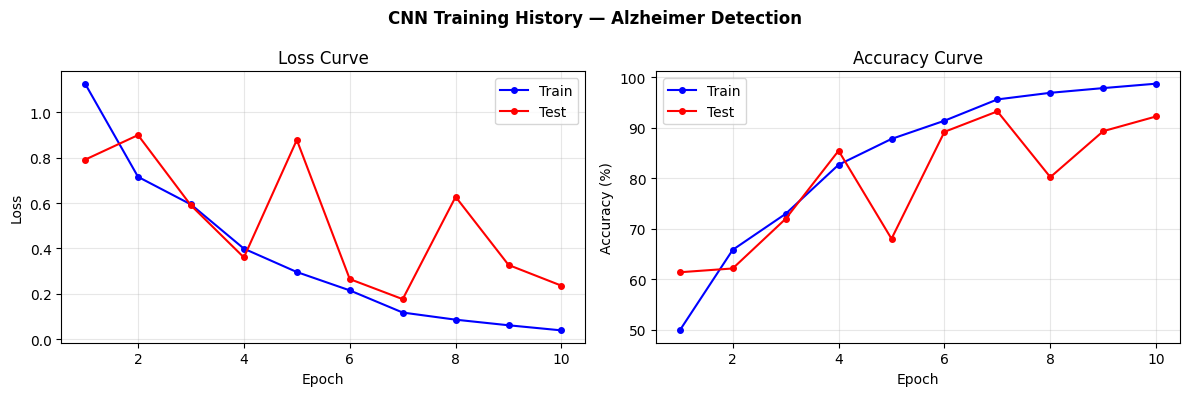

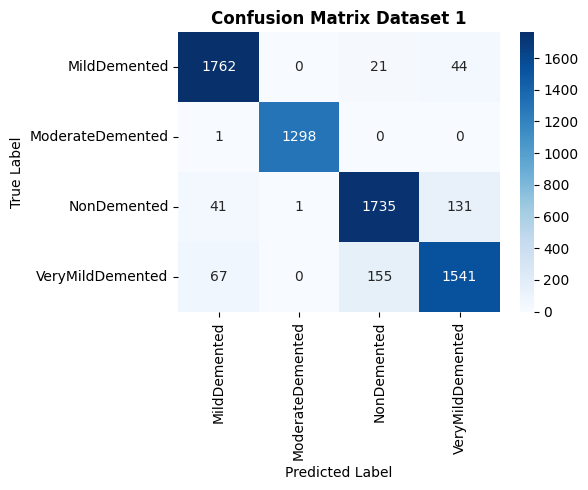

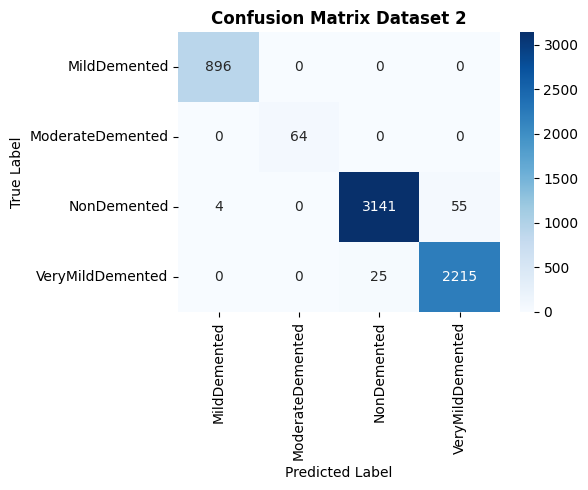

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

DATASET1_PATH = "./AugmentedAlzheimerDataset"
DATASET2_PATH = "./OriginalDataset"

CLASS_NAMES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
NUM_CLASSES = 4
IMG_SIZE    = 64        # reduced from 128 → 4x faster convolutions
BATCH_SIZE  = 64        # larger batch → fewer iterations per epoch
EPOCHS      = 10        # reduced from 15 → enough for convergence
LR          = 2e-3      # slightly higher LR → faster convergence
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")


# STEP 1 — PREPROCESSING

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),   
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),                          
    transforms.Normalize(mean=[0.5], std=[0.5])    
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


# STEP 2 — LOAD DATASETS


def get_loaders():
    full = ImageFolder(DATASET1_PATH, transform=train_transforms)
    train_size = int(0.8 * len(full))
    test_size  = len(full) - train_size
    train_set, test_set = random_split(
        full, [train_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    test_set.dataset.transform = test_transforms

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    val_set    = ImageFolder(DATASET2_PATH, transform=test_transforms)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f"Dataset 1 — Train: {train_size}  |  Test: {test_size}")
    print(f"Dataset 2 — Validation: {len(val_set)}")
    return train_loader, test_loader, val_loader

# STEP 3 — CNN MODEL

class AlzheimerCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(AlzheimerCNN, self).__init__()

        # --- Feature Extraction Blocks ---
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                             
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                             
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                             
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                             
        )

        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x


# STEP 4 — TRAINING

def train(model, train_loader, test_loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {"train_acc": [], "test_acc": [], "train_loss": [], "test_loss": []}
    best_acc = 0.0

    for epoch in range(EPOCHS):
        # ── Train ──
        model.train()
        correct, total, running_loss = 0, 0, 0.0

        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            correct      += out.argmax(1).eq(labels).sum().item()
            total        += labels.size(0)

        scheduler.step()

        train_acc  = 100 * correct / total
        train_loss = running_loss / total

        # ── Evaluate on Test ──
        t_acc, t_loss, _, _ = evaluate(model, test_loader, criterion)

        history["train_acc"].append(train_acc)
        history["test_acc"].append(t_acc)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(t_loss)

        print(f"  Train Acc: {train_acc:.2f}%  Loss: {train_loss:.4f}  |  "
              f"Test Acc: {t_acc:.2f}%  Loss: {t_loss:.4f}")

        if t_acc > best_acc:
            best_acc = t_acc
            torch.save(model.state_dict(), "best_cnn_model.pth")
            print(f"  ✓ Best model saved ({best_acc:.2f}%)")

    return history

# STEP 5 — EVALUATION

def evaluate(model, loader, criterion=None):
    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            if criterion:
                running_loss += criterion(out, labels).item() * imgs.size(0)
            preds    = out.argmax(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc  = 100 * correct / total
    loss = running_loss / total if criterion else 0
    return acc, loss, np.array(all_preds), np.array(all_labels)

# STEP 6 — PLOTS

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    e = range(1, len(history["train_acc"]) + 1)

    ax1.plot(e, history["train_loss"], 'b-o', markersize=4, label="Train")
    ax1.plot(e, history["test_loss"],  'r-o', markersize=4, label="Test")
    ax1.set_title("Loss Curve"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(e, history["train_acc"], 'b-o', markersize=4, label="Train")
    ax2.plot(e, history["test_acc"],  'r-o', markersize=4, label="Test")
    ax2.set_title("Accuracy Curve"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle("CNN Training History — Alzheimer Detection", fontweight="bold")
    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    print("Saved: training_history.png")

def plot_confusion(labels, preds, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(title, fontweight="bold")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.tight_layout()
    fname = title.replace(" ", "_").lower() + ".png"
    plt.savefig(fname, dpi=150)
    print(f"Saved: {fname}")
# MAIN
if __name__ == "__main__":
    print("\n=== STEP 1+2: Preprocessing & Loading Datasets ===")
    train_loader, test_loader, val_loader = get_loaders()

    print("\n=== STEP 3: Building CNN Model ===")
    model = AlzheimerCNN(num_classes=NUM_CLASSES).to(DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters    : {total:,}")
    print(f"Trainable parameters: {trainable:,}")
    print(model)

    print("\n=== STEP 4: Training CNN ===")
    history = train(model, train_loader, test_loader)
    plot_history(history)

    print("\n=== STEP 5: Loading Best Model ===")
    model.load_state_dict(torch.load("best_cnn_model.pth"))

    print("\n=== STEP 6a: Evaluate — Dataset 1 (Mendeley Test Set) ===")
    acc1, _, preds1, labels1 = evaluate(model, test_loader)
    print(f"Accuracy: {acc1:.2f}%")
    print(classification_report(labels1, preds1, target_names=CLASS_NAMES))
    plot_confusion(labels1, preds1, "Confusion Matrix Dataset 1")

    print("\n=== STEP 6b: Evaluate — Dataset 2 (OASIS Validation) ===")
    acc2, _, preds2, labels2 = evaluate(model, val_loader)
    print(f"Accuracy: {acc2:.2f}%")
    print(classification_report(labels2, preds2, target_names=CLASS_NAMES))
    plot_confusion(labels2, preds2, "Confusion Matrix Dataset 2")

    print("\n========== FINAL RESULTS ==========")
    print(f"Dataset 1 (Mendeley) Test Accuracy : {acc1:.2f}%")
    print(f"Dataset 2 (OASIS)    Val  Accuracy : {acc2:.2f}%")
    print("====================================")
